# Simulación del Flujo Portuario Segregado de Valparaíso — Entrega 3

**Modelamiento y Simulación de Eventos Discretos con SimPy**

Curso ICI 515 / INF 515 — Simulación de Eventos Discretos
Yoselin Cornejo · Daniel Belozo

---

Este notebook implementa, en SimPy, la red de colas del antepuerto de
Valparaíso (Camino La Pólvora → ZEAL) caracterizada estadísticamente en la
**Entrega 2**: llegada de camiones, paso por los Portales OCR, bifurcación
probabilística según tipo de carga, e inspección del SAG para la carga
agrícola. El objetivo es estresar computacionalmente el modelo, observar la
dinámica de las colas en el tiempo y comparar los tiempos de espera y
servicio de ambos servidores.

**Contenidos**

1. Librerías
2. Modelo
3. Estructuras
4. Funciones de Apoyo
5. Implementación del Simulador
6. Ejecución y Experimentos


## 1. Librerías

Se utilizan únicamente las librerías necesarias para modelar la red de
colas (`simpy`), generar las variables aleatorias del sistema (`numpy`),
graficar los resultados (`matplotlib`) y organizar/resumir las métricas
recolectadas (`collections.defaultdict`, `statistics`).


In [1]:
import numpy as np
import simpy
import matplotlib.pyplot as plt
from collections import defaultdict
import statistics

# Estilo general de los gráficos
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 2. Modelo

**Entidad:** camión frutícola o de carga general que arriba al antepuerto de
Valparaíso por el km 15 del Camino La Pólvora.

**Flujo lógico del camión** (idéntico al algoritmo validado en la Entrega 2):

1. **Llegada** — el camión arriba al sistema. Se registra `tiempo_llegada = env.now`.
2. **Servidor 1 — Portales OCR y Pesaje** (`recurso_ocr`, capacidad = 3):
   el camión hace fila, es atendido y se libera el recurso. Tiempo de
   servicio `TS_ocr ~ Triangular(3.0, 5.0, 8.0)` min.
3. **Bifurcación lógica** — con probabilidad empírica `p = 0.31` el camión
   es **Carga Agrícola (Reefer)** y continúa al Servidor 2; con probabilidad
   `1 − p = 0.69` es **Carga General** y salta directo al paso 5.
4. **Servidor 2 — Inspección SAG / Aduanas** (`recurso_sag`, capacidad = 20,
   solo carga agrícola): el camión hace fila, es inspeccionado y se libera
   el recurso. Tiempo de servicio `TS_sag ~ Lognormal(media=18.50, desv=4.30)` min.
5. **Convergencia y salida — Parqueadero ZEAL**: ambas rutas convergen en el
   buffer de la ZEAL. Se calcula el tiempo total de ciclo
   `tiempo_total = env.now − tiempo_llegada` y el camión sale del sistema.

**Proceso de llegada:** el tiempo entre llegadas (TAL) en el km 15 sigue una
distribución `Exponencial(media = 1.80 min)`, equivalente a una tasa
`λ = 1/1.80 ≈ 0.555` camiones/min.

Las tres distribuciones (Exponencial, Triangular y Lognormal) y sus
parámetros fueron seleccionadas y validadas estadísticamente en la Entrega 2
mediante las pruebas de Kolmogórov-Smirnov (TAL) y Chi-cuadrado (OCR y SAG),
no rechazándose la hipótesis nula en ninguno de los tres casos.


## 3. Estructuras

Se definen tres clases estáticas/contenedoras que ordenan el software:

- **`Parametros`** — configuración fija del experimento (capacidades,
  parámetros de las distribuciones, tamaño de muestra, horizonte de
  simulación).
- **`Salidas`** — bitácora "en caliente" de **una sola corrida**: listas de
  tiempos de espera y de servicio por servidor, y el historial de la
  evolución de las colas capturado por el proceso `snitch`.
- **`Experimentos`** — consolida los arreglos provenientes de **múltiples
  réplicas** para el análisis estadístico transversal (gráficos de
  evolución con banda de desviación estándar y boxplots comparativos).


In [2]:
class Parametros:
    """Configuración estática de la simulación."""

    # Tamaño de la muestra / horizonte temporal
    N_CAMIONES = 100          # camiones a generar por corrida
    TIEMPO_SIMULACION = 1000  # minutos (ticks de reloj) — horizonte de cada corrida
    N_REPLICAS = 10           # número de réplicas para los experimentos
    SEMILLA_BASE = 42

    # Servidor 1: Portales OCR y Pesaje
    CAP_OCR = 3
    OCR_MIN = 3.0
    OCR_MODA = 5.0
    OCR_MAX = 8.0

    # Bifurcación lógica (probabilidad empírica de carga agrícola/Reefer)
    PROB_SAG = 0.31

    # Servidor 2: Inspección SAG / Aduanas
    CAP_SAG = 20
    SAG_MEDIA = 18.50   # media de los datos originales (min)
    SAG_DESV = 4.30     # desviación estándar de los datos originales (min)

    # Proceso de llegada (TAL)
    MEDIA_TAL = 1.80              # min
    LAMBDA = 1 / MEDIA_TAL         # camiones/min

    # Buffer intermedio
    CAPACIDAD_ZEAL = 500

    # Bandera global de trazabilidad
    __DEBUG__ = False


class Salidas:
    """Bitácora en caliente de una sola corrida de simulación."""

    def __init__(self):
        # Tiempos de espera (en cola) por servidor
        self.tiempos_espera_ocr = []
        self.tiempos_espera_sag = []

        # Tiempos de servicio (atención) por servidor
        self.tiempos_servicio_ocr = []
        self.tiempos_servicio_sag = []

        # Tiempo total de ciclo por camión (llegada -> ZEAL)
        self.tiempos_totales = []

        # Clasificación de carga de cada camión
        self.tipos_carga = []

        # Evolución de la longitud de colas en el tiempo (proceso snitch)
        self.historial_tiempo = []
        self.historial_cola_ocr = []
        self.historial_cola_sag = []


class Experimentos:
    """Consolida los arreglos de múltiples réplicas para análisis transversal."""

    def __init__(self):
        self.esperas_ocr = []            # lista de listas (una por réplica)
        self.esperas_sag = []
        self.servicios_ocr = []
        self.servicios_sag = []
        self.tiempos_totales = []

        self.colas_ocr_por_replica = []  # una serie temporal por réplica
        self.colas_sag_por_replica = []
        self.ejes_tiempo = []


## 4. Funciones de Apoyo

### Trazabilidad (`LogEvent`)

Función de registro conectada a la bandera global `Parametros.__DEBUG__`:
si está activa, imprime en consola el evento junto con el tiempo de reloj
(`env.now`) en que ocurrió, permitiendo seguir paso a paso el recorrido de
cada camión.

### Muestreo periódico (`snitch`)

Proceso SimPy que, en cada tick de reloj, registra la longitud instantánea
de ambas colas (`len(recurso.queue)`), poblando `Salidas` con la dinámica
temporal del sistema.

### Generadores de variables aleatorias

Instancian con NumPy las tres distribuciones validadas en la Entrega 2:

- `generar_tal()` → `numpy.random.exponential(media)`.
- `generar_ts_ocr()` → `numpy.random.triangular(mín, moda, máx)`.
- `generar_ts_sag()` → `numpy.random.lognormal(mu, sigma)`.

**Nota sobre la Lognormal:** `numpy.random.lognormal(mean, sigma)` recibe
la media y la desviación estándar de `ln(X)` (la normal subyacente), **no**
las de `X`. Como en la Entrega 2 se reportó la media (18.50) y la
desviación estándar (4.30) de los datos originales `X`, se realiza la
conversión analítica estándar:

$$\sigma_{\ln}^2 = \ln\left(1 + \frac{\sigma_X^2}{\mu_X^2}\right)
\qquad\qquad
\mu_{\ln} = \ln(\mu_X) - \frac{\sigma_{\ln}^2}{2}$$


In [3]:
def LogEvent(env, mensaje):
    """Traza un evento en consola si Parametros.__DEBUG__ está activo."""
    if Parametros.__DEBUG__:
        print(f"[t={env.now:8.2f} min] {mensaje}")


def snitch(env, recurso_ocr, recurso_sag, salidas, intervalo=1.0):
    """Proceso de muestreo periódico: captura la longitud de ambas colas."""
    while True:
        salidas.historial_tiempo.append(env.now)
        salidas.historial_cola_ocr.append(len(recurso_ocr.queue))
        salidas.historial_cola_sag.append(len(recurso_sag.queue))
        yield env.timeout(intervalo)


def generar_tal():
    """Tiempo entre llegadas ~ Exponencial(media=1.80 min)."""
    return np.random.exponential(Parametros.MEDIA_TAL)


def generar_ts_ocr():
    """Tiempo de servicio OCR ~ Triangular(3.0, 5.0, 8.0) min."""
    return np.random.triangular(Parametros.OCR_MIN, Parametros.OCR_MODA, Parametros.OCR_MAX)


def _parametros_lognormal(media_datos, desv_datos):
    """Convierte media/desv. estándar de los datos (X) a los parámetros
    (mu, sigma) de la normal subyacente ln(X) que requiere NumPy."""
    sigma2 = np.log(1 + (desv_datos / media_datos) ** 2)
    mu = np.log(media_datos) - sigma2 / 2
    return mu, np.sqrt(sigma2)


_MU_SAG, _SIGMA_SAG = _parametros_lognormal(Parametros.SAG_MEDIA, Parametros.SAG_DESV)


def generar_ts_sag():
    """Tiempo de inspección SAG ~ Lognormal(media=18.50, desv=4.30) min."""
    return np.random.lognormal(_MU_SAG, _SIGMA_SAG)


def resumen_estadistico(nombre, datos):
    """Imprime n, media, desv. estándar, mínimo y máximo de una muestra."""
    media = statistics.mean(datos)
    desv = statistics.stdev(datos) if len(datos) > 1 else 0.0
    print(f"{nombre:28s} | n={len(datos):4d} | media={media:7.3f} min | "
          f"desv.est={desv:6.3f} min | mín={min(datos):6.3f} | máx={max(datos):6.3f}")


In [4]:
# Verificación rápida de la conversión de parámetros de la Lognormal:
# el promedio y la desv. estándar empíricos de una muestra grande deben
# acercarse a los valores reportados en la Entrega 2 (18.50 / 4.30).
_muestra_verificacion = np.random.lognormal(_MU_SAG, _SIGMA_SAG, size=200_000)
print(f"mu={_MU_SAG:.4f}  sigma={_SIGMA_SAG:.4f}")
print(f"media empírica ≈ {_muestra_verificacion.mean():.2f} min "
      f"(objetivo 18.50)  |  desv. est. empírica ≈ {_muestra_verificacion.std():.2f} min (objetivo 4.30)")


mu=2.8915  sigma=0.2294
media empírica ≈ 18.49 min (objetivo 18.50)  |  desv. est. empírica ≈ 4.31 min (objetivo 4.30)


## 5. Implementación del Simulador

Se modularizan los procesos de SimPy siguiendo la secuencia lógica exacta
del sistema:

- **`procesoLlegada`** — genera sucesivamente los `N_CAMIONES`, separados
  por un `TAL ~ Exponencial`, y lanza el proceso `camion` para cada uno.
- **`portal_ocr`** — función del Servidor 1: solicita `recurso_ocr`
  (`.request()`), espera su turno, ejecuta el servicio con
  `yield env.timeout(ts_ocr)` y libera el recurso (`.release()`).
- **`bahia_sag`** — función del Servidor 2, con la misma lógica de
  solicitud/servicio/liberación sobre `recurso_sag`.
- **`camion`** — proceso principal de la entidad: registra la llegada,
  invoca `portal_ocr` como subproceso, resuelve la bifurcación probabilística
  y, si corresponde, invoca `bahia_sag`; finalmente converge en el
  Parqueadero ZEAL y registra el tiempo total de ciclo.


In [5]:
def portal_ocr(env, recurso_ocr, id_camion, tiempo_llegada, salidas):
    """Servidor 1: Portales OCR y Pesaje (capacidad = 3)."""
    req = recurso_ocr.request()
    yield req

    espera_ocr = env.now - tiempo_llegada
    LogEvent(env, f"Camión {id_camion:03d}: ingresa a Portal OCR (espera={espera_ocr:.2f} min)")

    ts_ocr = generar_ts_ocr()
    yield env.timeout(ts_ocr)

    recurso_ocr.release(req)
    LogEvent(env, f"Camión {id_camion:03d}: libera Portal OCR (servicio={ts_ocr:.2f} min)")

    salidas.tiempos_espera_ocr.append(espera_ocr)
    salidas.tiempos_servicio_ocr.append(ts_ocr)
    return espera_ocr, ts_ocr


def bahia_sag(env, recurso_sag, id_camion, tiempo_llegada_sag, salidas):
    """Servidor 2: Inspección SAG / Aduanas (capacidad = 20)."""
    req = recurso_sag.request()
    yield req

    espera_sag = env.now - tiempo_llegada_sag
    LogEvent(env, f"Camión {id_camion:03d}: ingresa a bahía SAG (espera={espera_sag:.2f} min)")

    ts_sag = generar_ts_sag()
    yield env.timeout(ts_sag)

    recurso_sag.release(req)
    LogEvent(env, f"Camión {id_camion:03d}: libera bahía SAG (servicio={ts_sag:.2f} min)")

    salidas.tiempos_espera_sag.append(espera_sag)
    salidas.tiempos_servicio_sag.append(ts_sag)
    return espera_sag, ts_sag


def camion(env, id_camion, recurso_ocr, recurso_sag, salidas):
    """Proceso principal: recorrido completo de un camión por la red de colas."""

    # 1. EVENTO LLEGADA
    tiempo_llegada = env.now
    LogEvent(env, f"Camión {id_camion:03d}: LLEGADA al km 15 Camino La Pólvora")

    # 2. BLOQUE SERVIDOR 1 (Portales OCR)
    espera_ocr, ts_ocr = yield env.process(
        portal_ocr(env, recurso_ocr, id_camion, tiempo_llegada, salidas)
    )

    # 3. BIFURCACIÓN LÓGICA (probabilidad de carga)
    valor_aleatorio = np.random.uniform(0, 1)
    if valor_aleatorio <= Parametros.PROB_SAG:
        tipo_carga = "Agrícola (Reefer)"
        LogEvent(env, f"Camión {id_camion:03d}: bifurcación -> {tipo_carga} (u={valor_aleatorio:.3f})")

        # 4. BLOQUE SERVIDOR 2 (Inspección SAG) — solo carga agrícola
        # tiempo_llegada_sag == tiempo_llegada + espera_ocr + ts_ocr == env.now en este punto
        tiempo_llegada_sag = tiempo_llegada + espera_ocr + ts_ocr
        yield env.process(
            bahia_sag(env, recurso_sag, id_camion, tiempo_llegada_sag, salidas)
        )
    else:
        tipo_carga = "Carga General"
        LogEvent(env, f"Camión {id_camion:03d}: bifurcación -> {tipo_carga}, directo a ZEAL "
                       f"(u={valor_aleatorio:.3f})")

    salidas.tipos_carga.append(tipo_carga)

    # 5. CONVERGENCIA Y SALIDA (Parqueadero ZEAL)
    tiempo_total = env.now - tiempo_llegada
    salidas.tiempos_totales.append(tiempo_total)
    LogEvent(env, f"Camión {id_camion:03d}: ingresa a Parqueadero ZEAL (tiempo total={tiempo_total:.2f} min)")


def procesoLlegada(env, recurso_ocr, recurso_sag, salidas, n_camiones):
    """Genera la llegada sucesiva de camiones: TAL ~ Exponencial(media=1.80 min)."""
    for id_camion in range(1, n_camiones + 1):
        tal = generar_tal()
        yield env.timeout(tal)
        env.process(camion(env, id_camion, recurso_ocr, recurso_sag, salidas))


In [6]:
def ejecutar_simulacion(semilla=None, n_camiones=Parametros.N_CAMIONES,
                         tiempo_simulacion=Parametros.TIEMPO_SIMULACION, verbose=False):
    """Corre una única réplica de la simulación y devuelve su bitácora (Salidas)."""
    if semilla is not None:
        np.random.seed(semilla)
    Parametros.__DEBUG__ = verbose

    env = simpy.Environment()
    recurso_ocr = simpy.Resource(env, capacity=Parametros.CAP_OCR)
    recurso_sag = simpy.Resource(env, capacity=Parametros.CAP_SAG)
    salidas = Salidas()

    env.process(procesoLlegada(env, recurso_ocr, recurso_sag, salidas, n_camiones))
    env.process(snitch(env, recurso_ocr, recurso_sag, salidas))

    env.run(until=tiempo_simulacion)
    return salidas


## 6. Ejecución y Experimentos

Primero se realiza una **corrida única con trazabilidad activa** (`__DEBUG__ = True`)
para verificar visualmente que la secuencia lógica del camión (llegada → OCR
→ bifurcación → SAG opcional → ZEAL) se ejecuta correctamente. Luego se
corren **múltiples réplicas** (`Parametros.N_REPLICAS`) para consolidar el
análisis estadístico transversal: dinámica de colas en el tiempo (con banda
de ±1 desviación estándar) y boxplots comparativos de tiempos de espera y
de servicio.


In [7]:
# --- Corrida única de verificación (con trazabilidad) ---
salidas_demo = ejecutar_simulacion(semilla=1, n_camiones=10, tiempo_simulacion=200, verbose=True)


[t=    0.97 min] Camión 001: LLEGADA al km 15 Camino La Pólvora
[t=    0.97 min] Camión 001: ingresa a Portal OCR (espera=0.00 min)
[t=    3.26 min] Camión 002: LLEGADA al km 15 Camino La Pólvora
[t=    3.26 min] Camión 002: ingresa a Portal OCR (espera=0.00 min)
[t=    3.91 min] Camión 003: LLEGADA al km 15 Camino La Pólvora
[t=    3.91 min] Camión 003: ingresa a Portal OCR (espera=0.00 min)
[t=    4.01 min] Camión 001: libera Portal OCR (servicio=3.03 min)
[t=    4.01 min] Camión 001: bifurcación -> Carga General, directo a ZEAL (u=0.346)
[t=    4.01 min] Camión 001: ingresa a Parqueadero ZEAL (tiempo total=3.03 min)
[t=    4.09 min] Camión 004: LLEGADA al km 15 Camino La Pólvora
[t=    4.09 min] Camión 004: ingresa a Portal OCR (espera=0.00 min)
[t=    5.00 min] Camión 005: LLEGADA al km 15 Camino La Pólvora
[t=    5.97 min] Camión 006: LLEGADA al km 15 Camino La Pólvora
[t=    7.48 min] Camión 002: libera Portal OCR (servicio=4.21 min)
[t=    7.48 min] Camión 002: bifurcación -> Ag

In [8]:
# --- Corrida única "de producción" (sin trazabilidad) para revisar sus métricas ---
salidas_unica = ejecutar_simulacion(semilla=Parametros.SEMILLA_BASE, verbose=False)

print("Resumen de la corrida única")
print("-" * 90)
resumen_estadistico("Espera en Portal OCR", salidas_unica.tiempos_espera_ocr)
resumen_estadistico("Servicio en Portal OCR", salidas_unica.tiempos_servicio_ocr)
resumen_estadistico("Espera en bahía SAG", salidas_unica.tiempos_espera_sag)
resumen_estadistico("Servicio en bahía SAG", salidas_unica.tiempos_servicio_sag)
resumen_estadistico("Tiempo total de ciclo", salidas_unica.tiempos_totales)

n_agricola = salidas_unica.tipos_carga.count("Agrícola (Reefer)")
n_general = salidas_unica.tipos_carga.count("Carga General")
print(f"\nCamiones simulados: {len(salidas_unica.tipos_carga)}  |  "
      f"Agrícola (Reefer): {n_agricola} ({n_agricola/len(salidas_unica.tipos_carga):.1%})  |  "
      f"Carga General: {n_general} ({n_general/len(salidas_unica.tipos_carga):.1%})")


Resumen de la corrida única
------------------------------------------------------------------------------------------
Espera en Portal OCR         | n= 100 | media=  8.338 min | desv.est= 5.388 min | mín= 0.000 | máx=20.112
Servicio en Portal OCR       | n= 100 | media=  5.279 min | desv.est= 0.966 min | mín= 3.264 | máx= 7.349
Espera en bahía SAG          | n=  31 | media=  0.000 min | desv.est= 0.000 min | mín= 0.000 | máx= 0.000
Servicio en bahía SAG        | n=  31 | media= 20.363 min | desv.est= 3.438 min | mín=12.449 | máx=27.684
Tiempo total de ciclo        | n= 100 | media= 19.929 min | desv.est=11.282 min | mín= 4.400 | máx=50.188

Camiones simulados: 100  |  Agrícola (Reefer): 31 (31.0%)  |  Carga General: 69 (69.0%)


### Múltiples réplicas (`Experimentos`)

Se ejecutan `Parametros.N_REPLICAS` corridas independientes (una semilla
distinta por réplica) y se consolidan sus resultados en una instancia de
`Experimentos` para el análisis gráfico transversal.


In [9]:
def ejecutar_experimentos(n_replicas=Parametros.N_REPLICAS, n_camiones=Parametros.N_CAMIONES,
                           tiempo_simulacion=Parametros.TIEMPO_SIMULACION):
    """Corre múltiples réplicas y consolida sus resultados en Experimentos."""
    experimentos = Experimentos()

    for r in range(n_replicas):
        semilla = Parametros.SEMILLA_BASE + r
        salidas = ejecutar_simulacion(
            semilla=semilla, n_camiones=n_camiones,
            tiempo_simulacion=tiempo_simulacion, verbose=False,
        )

        experimentos.esperas_ocr.append(salidas.tiempos_espera_ocr)
        experimentos.esperas_sag.append(salidas.tiempos_espera_sag)
        experimentos.servicios_ocr.append(salidas.tiempos_servicio_ocr)
        experimentos.servicios_sag.append(salidas.tiempos_servicio_sag)
        experimentos.tiempos_totales.append(salidas.tiempos_totales)

        experimentos.colas_ocr_por_replica.append(salidas.historial_cola_ocr)
        experimentos.colas_sag_por_replica.append(salidas.historial_cola_sag)
        experimentos.ejes_tiempo.append(salidas.historial_tiempo)

    return experimentos


experimentos = ejecutar_experimentos()
print(f"{Parametros.N_REPLICAS} réplicas ejecutadas "
      f"({Parametros.N_CAMIONES} camiones cada una, horizonte de {Parametros.TIEMPO_SIMULACION} min).")


10 réplicas ejecutadas (100 camiones cada una, horizonte de 1000 min).


### Dinámica de crecimiento de las colas

Se grafica, para ambos servidores, el promedio de la longitud de cola en
cada instante de tiempo a través de las réplicas, con una banda sombreada
de ±1 desviación estándar.


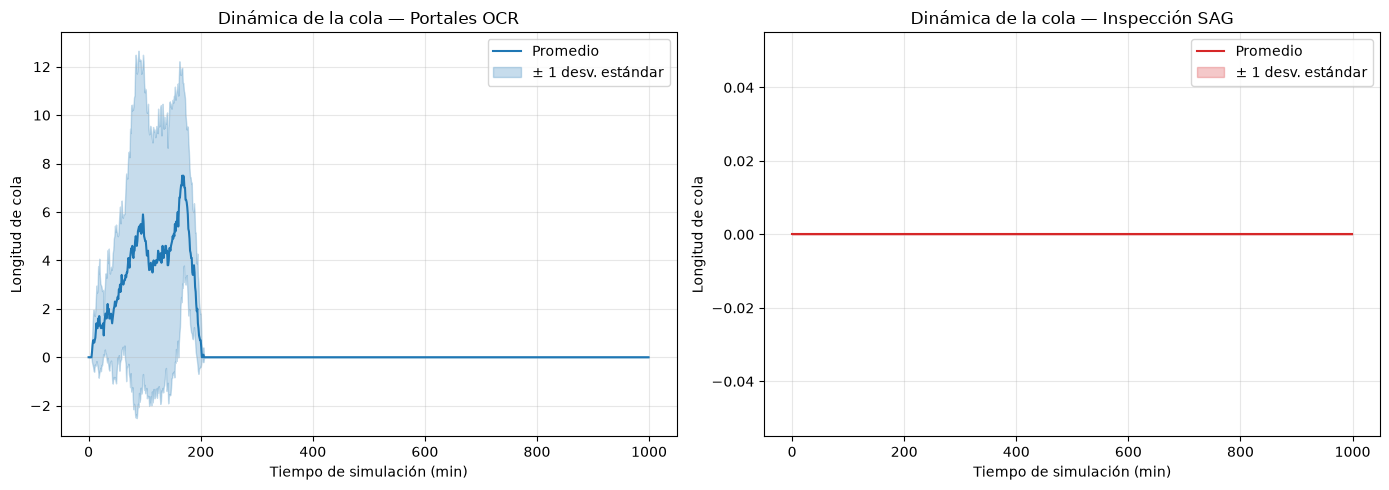

In [10]:
def graficar_evolucion_colas(experimentos):
    """Evolución temporal de la longitud de cola (promedio ± desv. estándar)."""
    colas_ocr = np.array(experimentos.colas_ocr_por_replica)
    colas_sag = np.array(experimentos.colas_sag_por_replica)
    eje_tiempo = np.array(experimentos.ejes_tiempo[0])

    media_ocr, std_ocr = colas_ocr.mean(axis=0), colas_ocr.std(axis=0)
    media_sag, std_sag = colas_sag.mean(axis=0), colas_sag.std(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(eje_tiempo, media_ocr, color="#1f77b4", label="Promedio")
    axes[0].fill_between(eje_tiempo, media_ocr - std_ocr, media_ocr + std_ocr,
                          alpha=0.25, color="#1f77b4", label="± 1 desv. estándar")
    axes[0].set_title("Dinámica de la cola — Portales OCR")
    axes[0].set_xlabel("Tiempo de simulación (min)")
    axes[0].set_ylabel("Longitud de cola")
    axes[0].legend()

    axes[1].plot(eje_tiempo, media_sag, color="#d62728", label="Promedio")
    axes[1].fill_between(eje_tiempo, media_sag - std_sag, media_sag + std_sag,
                          alpha=0.25, color="#d62728", label="± 1 desv. estándar")
    axes[1].set_title("Dinámica de la cola — Inspección SAG")
    axes[1].set_xlabel("Tiempo de simulación (min)")
    axes[1].set_ylabel("Longitud de cola")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


graficar_evolucion_colas(experimentos)


### Comparación de Tiempos de Espera y de Servicio

Diagramas de caja que agrupan, a través de todas las réplicas, los tiempos
de espera y los tiempos de servicio observados en cada servidor.


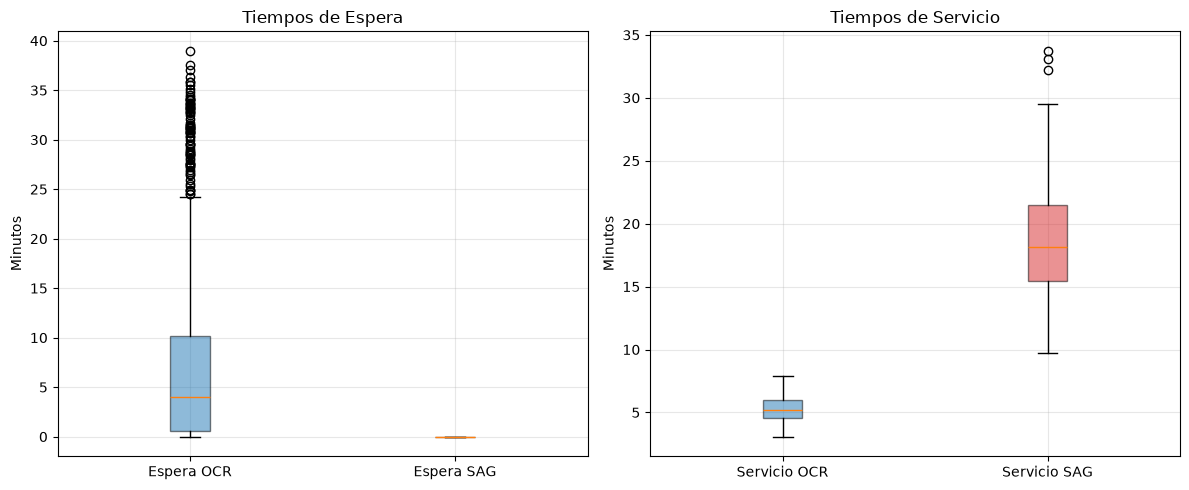

In [11]:
def graficar_boxplots(experimentos):
    """Boxplots comparativos de tiempos de espera y de servicio por servidor."""
    esperas_ocr = [t for replica in experimentos.esperas_ocr for t in replica]
    esperas_sag = [t for replica in experimentos.esperas_sag for t in replica]
    servicios_ocr = [t for replica in experimentos.servicios_ocr for t in replica]
    servicios_sag = [t for replica in experimentos.servicios_sag for t in replica]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    caja1 = axes[0].boxplot([esperas_ocr, esperas_sag],
                             tick_labels=["Espera OCR", "Espera SAG"], patch_artist=True)
    for parche, color in zip(caja1["boxes"], ["#1f77b4", "#d62728"]):
        parche.set_facecolor(color)
        parche.set_alpha(0.5)
    axes[0].set_title("Tiempos de Espera")
    axes[0].set_ylabel("Minutos")

    caja2 = axes[1].boxplot([servicios_ocr, servicios_sag],
                             tick_labels=["Servicio OCR", "Servicio SAG"], patch_artist=True)
    for parche, color in zip(caja2["boxes"], ["#1f77b4", "#d62728"]):
        parche.set_facecolor(color)
        parche.set_alpha(0.5)
    axes[1].set_title("Tiempos de Servicio")
    axes[1].set_ylabel("Minutos")

    plt.tight_layout()
    plt.show()

    return esperas_ocr, esperas_sag, servicios_ocr, servicios_sag


esperas_ocr, esperas_sag, servicios_ocr, servicios_sag = graficar_boxplots(experimentos)


### Resumen estadístico transversal

Estadísticos descriptivos consolidados sobre las `Parametros.N_REPLICAS`
réplicas, útiles como línea base para la siguiente fase del proyecto
(experimentación con reglas de prioridad y dimensionamiento de
infraestructura).


In [12]:
print("Resumen estadístico transversal — todas las réplicas")
print("-" * 90)
resumen_estadistico("Espera en Portal OCR", esperas_ocr)
resumen_estadistico("Servicio en Portal OCR", servicios_ocr)
resumen_estadistico("Espera en bahía SAG", esperas_sag)
resumen_estadistico("Servicio en bahía SAG", servicios_sag)

tiempos_totales_todos = [t for replica in experimentos.tiempos_totales for t in replica]
resumen_estadistico("Tiempo total de ciclo", tiempos_totales_todos)


Resumen estadístico transversal — todas las réplicas
------------------------------------------------------------------------------------------
Espera en Portal OCR         | n=1000 | media=  7.169 min | desv.est= 8.686 min | mín= 0.000 | máx=39.001
Servicio en Portal OCR       | n=1000 | media=  5.300 min | desv.est= 1.021 min | mín= 3.078 | máx= 7.907
Espera en bahía SAG          | n= 311 | media=  0.000 min | desv.est= 0.000 min | mín= 0.000 | máx= 0.000
Servicio en bahía SAG        | n= 311 | media= 18.610 min | desv.est= 4.321 min | mín= 9.713 | máx=33.751
Tiempo total de ciclo        | n=1000 | media= 18.257 min | desv.est=12.822 min | mín= 3.078 | máx=71.606


## Conclusión preliminar

La simulación reproduce fielmente la caracterización estadística obtenida
en la Entrega 2: la cola del Portal OCR se mantiene acotada gracias a sus
tres servidores y al techo físico del proceso mecánico (Triangular),
mientras que la bahía SAG — con inspección manual y cola larga (Lognormal)
— concentra la mayor variabilidad del sistema. Esta línea base cuantitativa
deja preparado el terreno para, en la siguiente fase, experimentar con
reglas de prioridad y escenarios de dimensionamiento de infraestructura que
mitiguen los puntos de quiebre detectados en temporada alta.
